In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc

In [2]:
class option_market:
    def __init__(self,S0,sigma,r,delta):
        self.S0 = S0
        self.sigma = sigma
        self.r = r
        self.delta = delta
    
    def crr_opt_eur(self,T,K,N,payoff_func):
        S0 =  self.S0 
        sigma =self.sigma 
        r = self.r
        delta = self.delta 
        delta_t = T/N
        delta_t = T/N

        u = np.exp(sigma*np.sqrt(delta_t))
        d = 1/u
        q_u = (np.exp((r-delta)*delta_t)-d)/(u-d)
        q_d = 1-q_u 
        endpoints = np.full(shape=(N+1,N+1),fill_value=np.nan)
        ends = lambda i,j : S0* u**(j-i) * d**i
        for n in range(N+1):
            for i in range(n+1):
                endpoints[i,n]=ends(i,n)

        p = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N,-1,-1):
            for j in range(i+1):
                p[j,i] = payoff_func(endpoints[j,i],K)

        v = np.full(shape=(N,N),fill_value=np.nan)
        for i in range(N-1,-1,-1):
            for j in range(i+1):
                if i == N-1:
                    v[j,i] =np.exp(-r*delta_t)*(q_u*p[j,i+1]+q_d*p[j+1,i+1])
                else:
                    v[j,i] = np.exp(-r*delta_t)*(q_u*v[j,i+1]+q_d*v[j+1,i+1])
        
        return v,endpoints[1:,1:]

    def crr_opt_am(self,T,K,N,payoff_func):
            
        S0 =  self.S0 
        sigma =self.sigma 
        r = self.r
        delta = self.delta 
        delta_t = T/N
        delta_t = T/N

        u = np.exp(sigma*np.sqrt(delta_t))
        d = 1/u
        q_u = (np.exp((r-delta)*delta_t)-d)/(u-d)
        q_d = 1-q_u 
        endpoints = np.full(shape=(N+1,N+1),fill_value=np.nan)
        ends = lambda i,j : S0* u**(j-i) * d**i
        for n in range(N+1):
            for i in range(n+1):
                endpoints[i,n]=ends(i,n)

        p = np.full(shape=(N+1,N+1),fill_value=np.nan)
        for i in range(N,-1,-1):
            for j in range(i+1):
                p[j,i] = payoff_func(endpoints[j,i],K)

        v = np.full(shape=(N,N),fill_value=np.nan)
        for i in range(N-1,-1,-1):
            for j in range(i+1):
                if i == N-1:
                    v[j,i] = np.maximum(p[j,i],np.exp(-r*delta_t)*(q_u*p[j,i+1]+q_d*p[j+1,i+1]))
                else:
                    v[j,i] = np.maximum(p[j,i],np.exp(-r*delta_t)*(q_u*v[j,i+1]+q_d*v[j+1,i+1])) 
        
        return v,endpoints[1:,1:]
    
    # def EEP(self,):

    #     return 





In [3]:
put = lambda S,K : np.maximum(K-S,0)
market1 = option_market(S0=100,sigma=0.2,r=0.02,delta=0.01)

eur_put,s = market1.crr_opt_eur(T=1/2,K=100,N=100,payoff_func=put)
am_put,s = market1.crr_opt_am(T=1/2,K=100,N=100,payoff_func=put)
EEP_put = am_put-eur_put

In [4]:
print(eur_put[0,0])
print(am_put[0,0])

5.3364742356930766
5.379817040498354


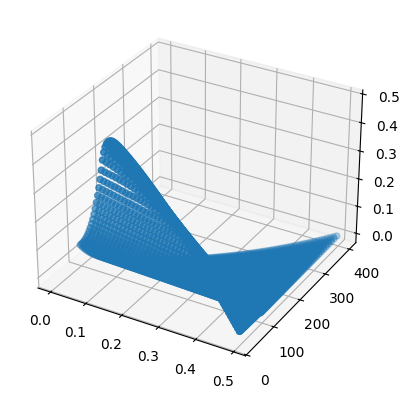

In [20]:
T = 1/2; N =100
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(np.arange(s.shape[0])*(T/N),s,EEP_put)
plt.show()

C:\Users\trist\AppData\Local\Temp\ipykernel_78008\1820530035.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(x, y, masked_z, shading="nearest", cmap="viridis")


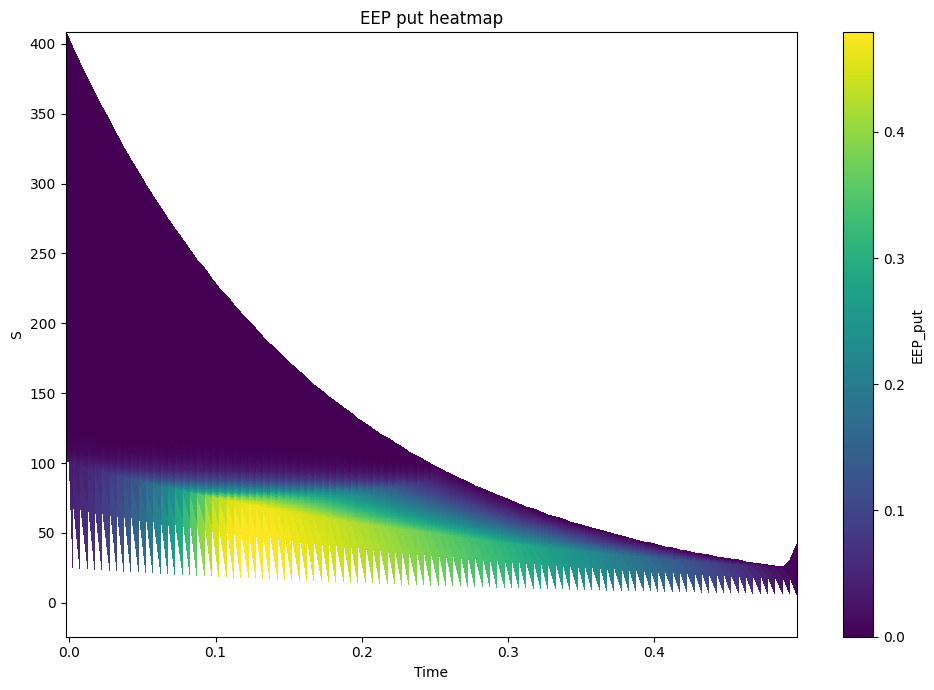

In [22]:
import numpy.ma as ma

T = 1/2; N = 100
time = np.arange(s.shape[0]) * (T / N)

# x = time, broadcast to NxN
x = np.tile(time, (s.shape[1], 1)).T

# y = s values, fill NaNs for valid coords
y = np.where(np.isnan(s), 0, s)

# Mask the NaN triangle
masked_z = ma.masked_where(np.isnan(s), EEP_put)

fig, ax = plt.subplots(figsize=(10, 7))
pcm = ax.pcolormesh(x, y, masked_z, shading="nearest", cmap="viridis")
fig.colorbar(pcm, ax=ax, label="EEP_put")
ax.set_xlabel("Time")
ax.set_ylabel("S")
ax.set_title("EEP put heatmap")
plt.tight_layout()
plt.show()